## Customer Churn Prediction - Task 1

This notebook analyzes customer churn behavior, builds predictive models, segments customers by value, and translates the findings into business recommendations.

**Project coverage**
- Data loading and cleaning
- Exploratory data analysis
- Feature engineering
- Visualizations and trends
- Machine learning evaluation
- Customer segmentation
- Risk prediction and business insights

**Data Analysis Module**

This section covers the full churn analysis pipeline from raw data inspection to business recommendations.

## 1. Data Loading

The dataset is loaded from the CSV file and stored in a pandas DataFrame for analysis.

In [56]:
import pandas as pd
df=pd.read_csv(r"D:\Intership\WA_Fn-UseC_-Telco-Customer-Churn.csv")


## 2. Initial Inspection

This step checks the structure of the dataset, the data types, and the first few records to understand what information is available.

In [57]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [58]:
df.tail(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [59]:
df.shape

(7043, 21)

In [60]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [61]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [63]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [64]:
df.duplicated().sum()

np.int64(0)

In [65]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [66]:
df['gender'].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [67]:
numerical_cols = df.select_dtypes(include=['int64','float64'])
print(numerical_cols.columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')


In [68]:
categorical_cols = df.select_dtypes(include=['object'])
print(categorical_cols.columns)

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')


## 3. Data Quality & Cleaning

In [69]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].dtype


dtype('float64')

In [70]:
(df.isnull().sum() / len(df)) * 100 # This helps to decide whether a column should be cleaned or removed.


customerID          0.000000
gender              0.000000
SeniorCitizen       0.000000
Partner             0.000000
Dependents          0.000000
tenure              0.000000
PhoneService        0.000000
MultipleLines       0.000000
InternetService     0.000000
OnlineSecurity      0.000000
OnlineBackup        0.000000
DeviceProtection    0.000000
TechSupport         0.000000
StreamingTV         0.000000
StreamingMovies     0.000000
Contract            0.000000
PaperlessBilling    0.000000
PaymentMethod       0.000000
MonthlyCharges      0.000000
TotalCharges        0.156183
Churn               0.000000
dtype: float64

So based on these results, none of the columns should be removed because of missing data. 
Only TotalCharges needs a small amount of cleaning.

So only about 11 records have missing values.

What should I do?

Since the missing percentage is very small (less than 1%), it would be better to keep column and clean the missing values rather than remove the entire column.

Common options:
Remove the rows with missing values (simple and often acceptable here):
df = df.dropna(subset=['TotalCharges'])

Fill the missing values with the median or mean:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

In [71]:
print(df[df['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'TotalCharges']])

      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754       0           61.90           NaN


In [72]:
df = df.dropna(subset=['TotalCharges'])

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

As in all 11 rows where total chages is missing has 0 tenure means user only sign-in and has no billing history.
soooooooooooo...
it would be better to drop those rows instead of filling those user total chages with mean/median who have not even use this app.

## 4. Outlier Detection

In [74]:
# now we check for outliers in all numerical columns using formula:
# The formula is:
#                  IQR=Q3−Q1

# A value is considered an outlier if it is:

#                           <Q1−1.5×IQR      OR        >Q3+1.5×IQR


df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

# Outlier analysis was conducted on the numerical features tenure, MonthlyCharges, and TotalCharges using 
# the Interquartile Range (IQR) method. The minimum and maximum values for all three variables fell within
#  the calculated IQR bounds, indicating that no significant outliers were present in the dataset. Therefore, 
# no outlier treatment was required.

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [75]:
# Count how many customers churned vs didn't
df['Churn'].value_counts()


Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [76]:
# Show it as percentage
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

## 1. Summary Statistics

This section provides a high-level overview of the dataset before modeling.

### Dataset Overview
- Total records: 7,032 customers
- Total features: 21 columns
- Target variable: Churn (Yes/No)
- Churn rate: 26.5% (1,869 churned out of 7,032)

### Data Quality Issues Found & Resolved
- TotalCharges column was incorrectly stored as text (object) instead of 
  number. Converted to float64.
- 11 rows had missing TotalCharges values. Investigation showed all had 
  tenure=0 (new customers with no billing history). These rows were dropped.
- No outliers detected in numerical columns (tenure, MonthlyCharges, 
  TotalCharges).

### Key Observations
- After cleaning tenure ranges from 1 to 72 months (1 to 6 years)
- MonthlyCharges ranges from $18.25 to $118.75
- TotalCharges ranges from $18.80 to $8,684.80
- Dataset has class imbalance: 73.5% No churn vs 26.5% Yes churn
  This means accuracy alone will be a misleading evaluation metric.

## Exploratory Data Analysis (EDA)

In this section I explored the data visually to understand 
patterns and find what makes churned customers different 
from customers who stayed. I checked churn distribution, 
contract type, tenure, monthly charges, internet service, 
and correlation between numerical columns.

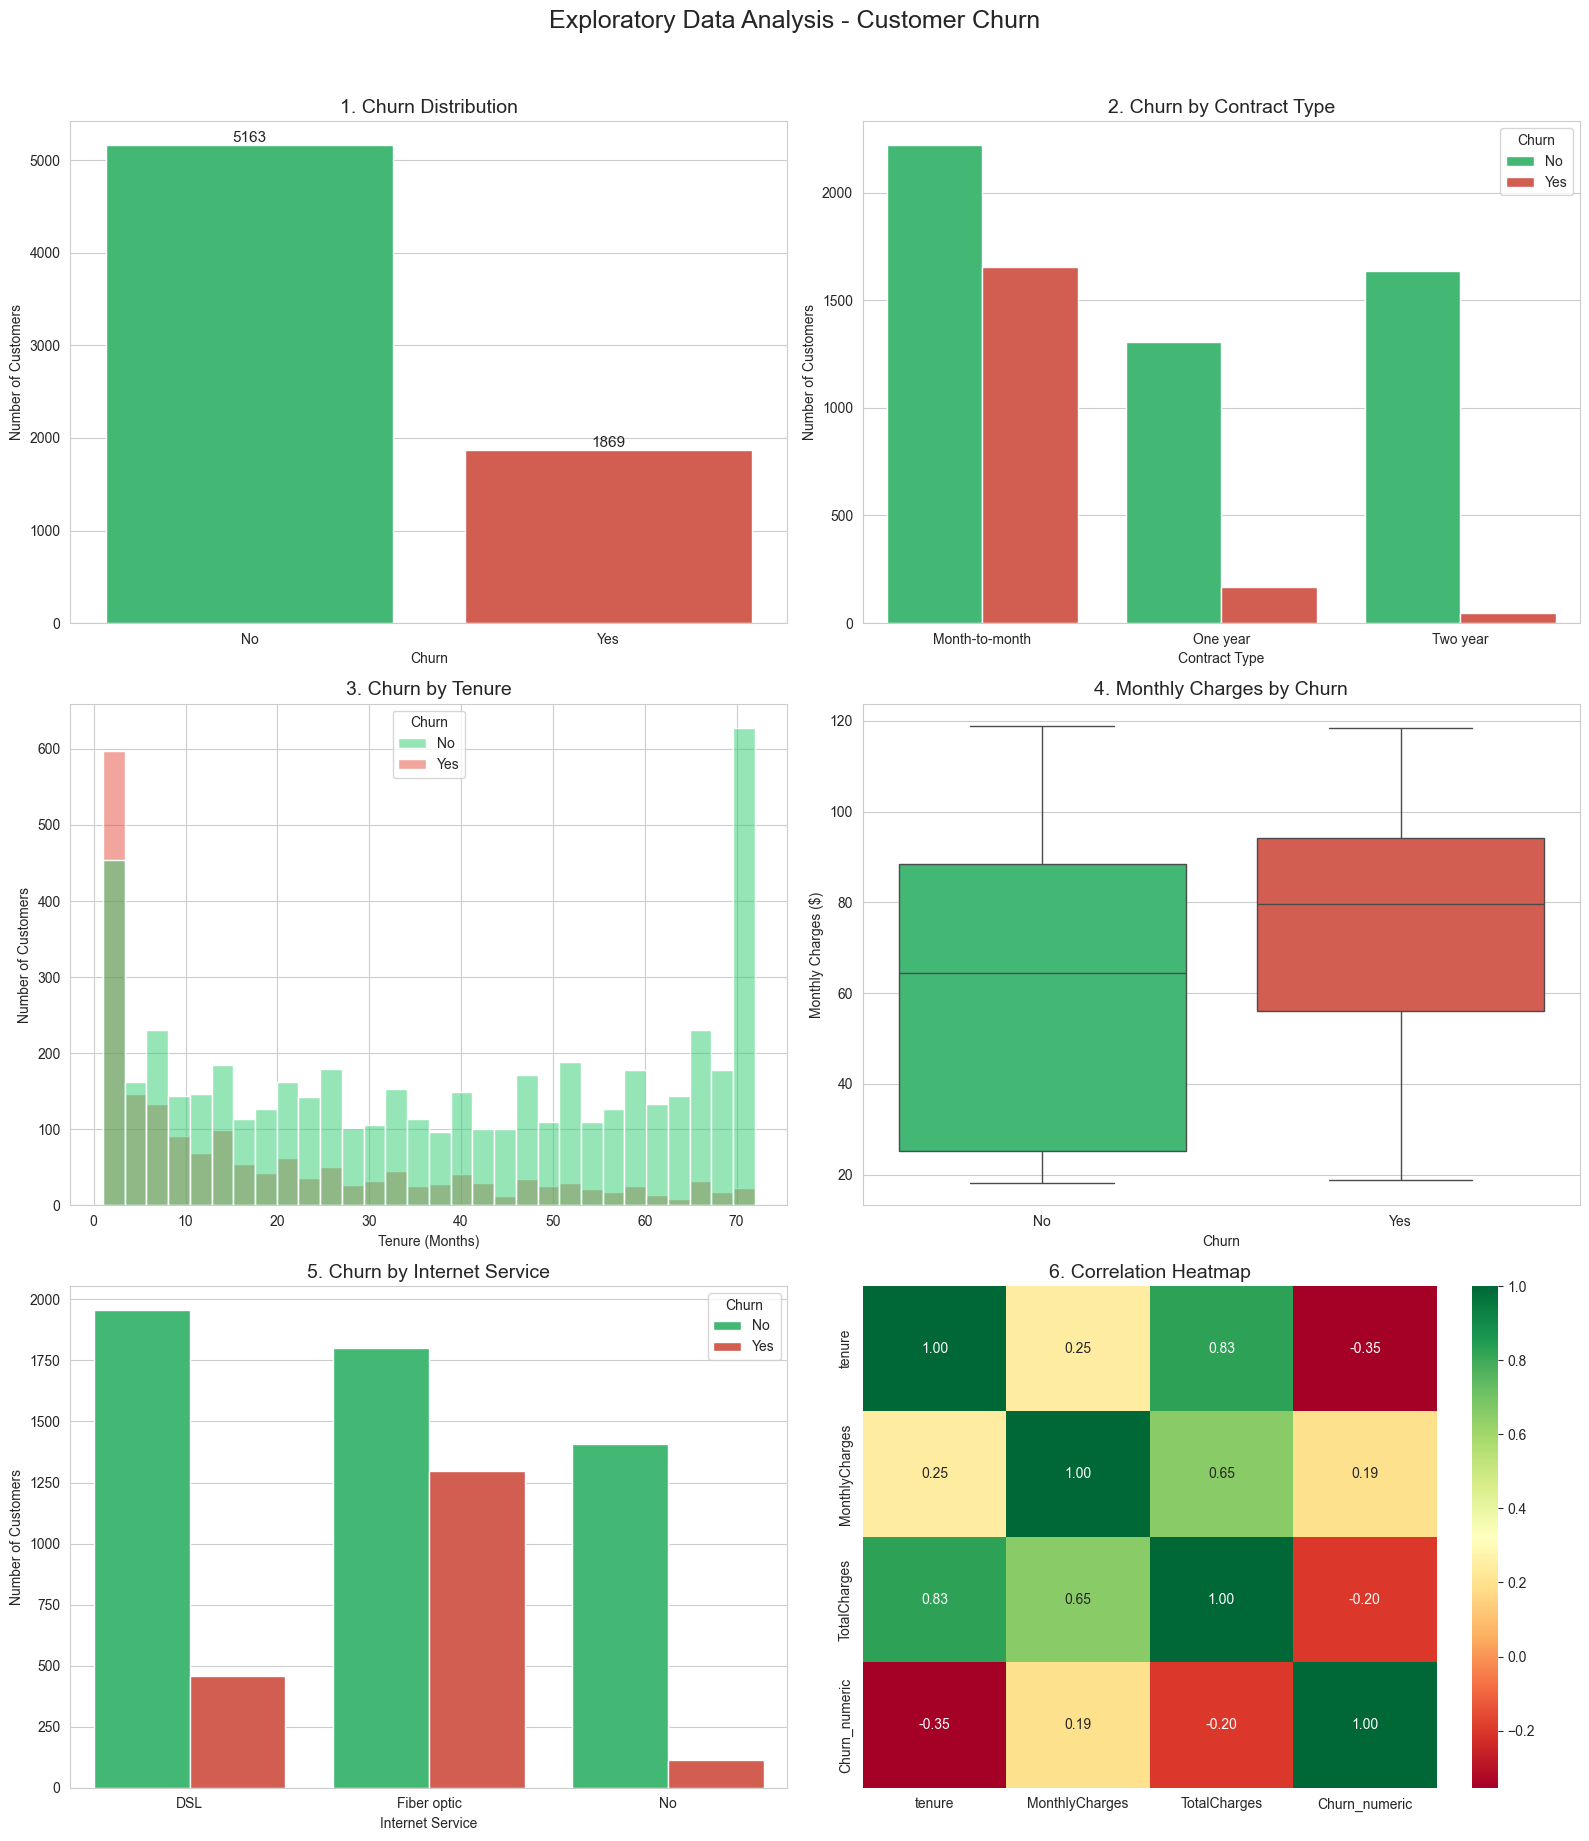

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Chart 1 - Churn Distribution
sns.countplot(data=df, x='Churn', 
              palette=['#2ecc71', '#e74c3c'], ax=axes[0,0])
axes[0,0].set_title('1. Churn Distribution', fontsize=14)
axes[0,0].set_xlabel('Churn')
axes[0,0].set_ylabel('Number of Customers')
for p in axes[0,0].patches:
    axes[0,0].annotate(f'{int(p.get_height())}',
                      (p.get_x() + p.get_width()/2., p.get_height()),
                      ha='center', va='bottom', fontsize=11)

# Chart 2 - Churn vs Contract Type
sns.countplot(data=df, x='Contract', hue='Churn',
              palette=['#2ecc71', '#e74c3c'], ax=axes[0,1])
axes[0,1].set_title('2. Churn by Contract Type', fontsize=14)
axes[0,1].set_xlabel('Contract Type')
axes[0,1].set_ylabel('Number of Customers')
axes[0,1].legend(title='Churn')

# Chart 3 - Churn vs Tenure
sns.histplot(data=df, x='tenure', hue='Churn',
             bins=30, palette=['#2ecc71', '#e74c3c'], ax=axes[1,0])
axes[1,0].set_title('3. Churn by Tenure', fontsize=14)
axes[1,0].set_xlabel('Tenure (Months)')
axes[1,0].set_ylabel('Number of Customers')

# Chart 4 - Churn vs Monthly Charges
sns.boxplot(data=df, x='Churn', y='MonthlyCharges',
            palette=['#2ecc71', '#e74c3c'], ax=axes[1,1])
axes[1,1].set_title('4. Monthly Charges by Churn', fontsize=14)
axes[1,1].set_xlabel('Churn')
axes[1,1].set_ylabel('Monthly Charges ($)')

# Chart 5 - Churn vs Internet Service
sns.countplot(data=df, x='InternetService', hue='Churn',
              palette=['#2ecc71', '#e74c3c'], ax=axes[2,0])
axes[2,0].set_title('5. Churn by Internet Service', fontsize=14)
axes[2,0].set_xlabel('Internet Service')
axes[2,0].set_ylabel('Number of Customers')
axes[2,0].legend(title='Churn')

# Chart 6 - Correlation Heatmap
df['Churn_numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges',
                'Churn_numeric']].corr(),
            annot=True, cmap='RdYlGn', fmt='.2f', ax=axes[2,1])
axes[2,1].set_title('6. Correlation Heatmap', fontsize=14)

plt.suptitle('Exploratory Data Analysis - Customer Churn', 
             fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

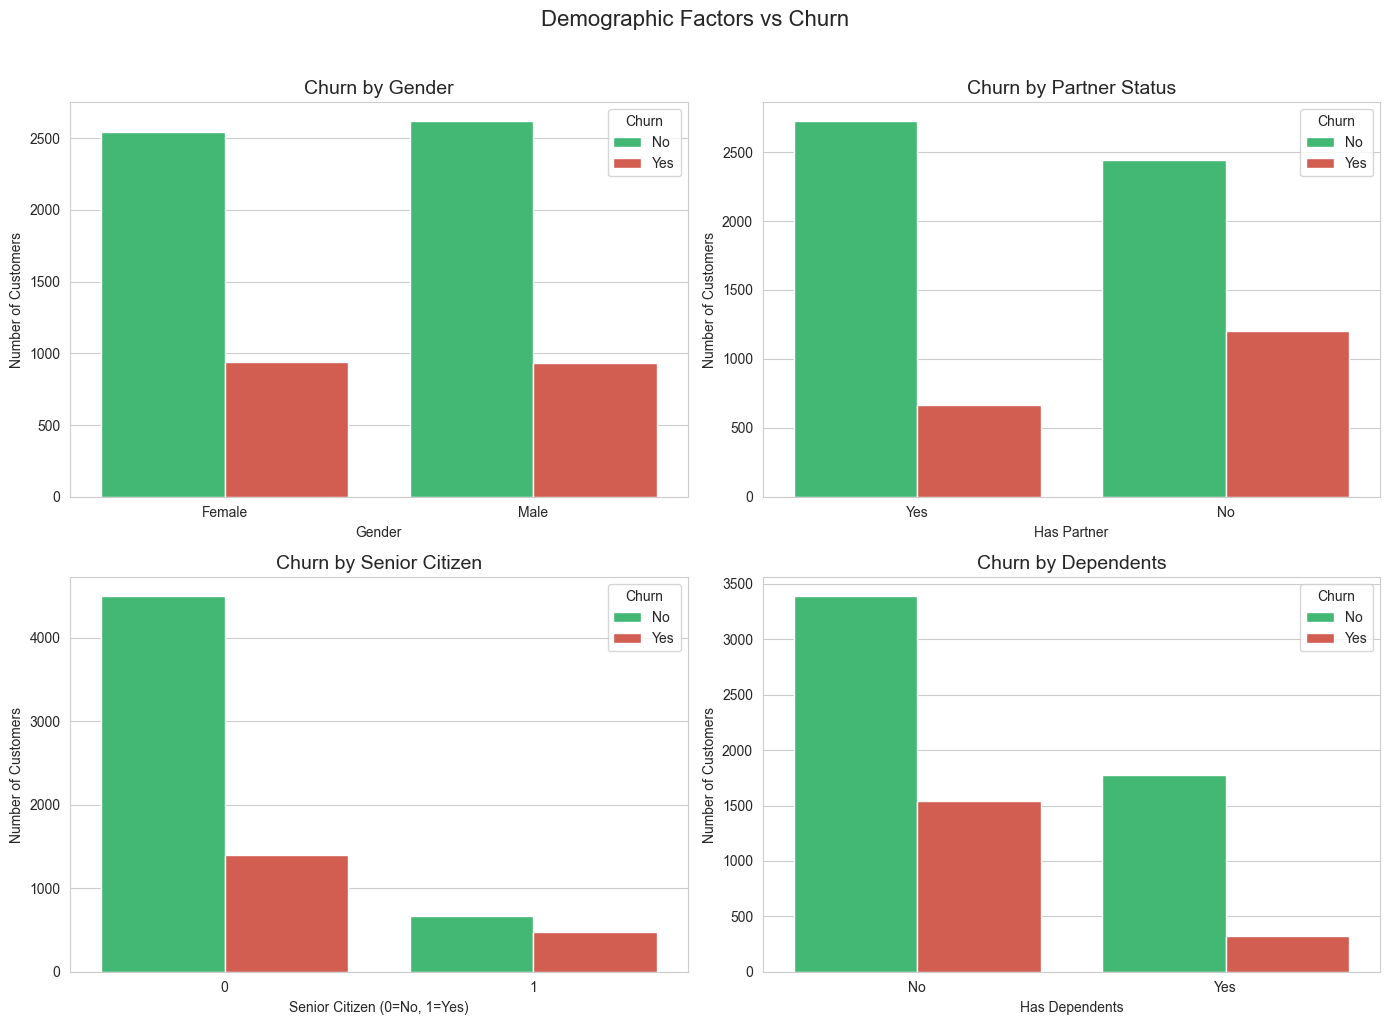

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gender vs Churn
sns.countplot(data=df, x='gender', hue='Churn',
              palette=['#2ecc71', '#e74c3c'], ax=axes[0,0])
axes[0,0].set_title('Churn by Gender', fontsize=14)
axes[0,0].set_xlabel('Gender')
axes[0,0].set_ylabel('Number of Customers')
axes[0,0].legend(title='Churn')

# Partner vs Churn
sns.countplot(data=df, x='Partner', hue='Churn',
              palette=['#2ecc71', '#e74c3c'], ax=axes[0,1])
axes[0,1].set_title('Churn by Partner Status', fontsize=14)
axes[0,1].set_xlabel('Has Partner')
axes[0,1].set_ylabel('Number of Customers')
axes[0,1].legend(title='Churn')

# SeniorCitizen vs Churn
sns.countplot(data=df, x='SeniorCitizen', hue='Churn',
              palette=['#2ecc71', '#e74c3c'], ax=axes[1,0])
axes[1,0].set_title('Churn by Senior Citizen', fontsize=14)
axes[1,0].set_xlabel('Senior Citizen (0=No, 1=Yes)')
axes[1,0].set_ylabel('Number of Customers')
axes[1,0].legend(title='Churn')

# Dependents vs Churn
sns.countplot(data=df, x='Dependents', hue='Churn',
              palette=['#2ecc71', '#e74c3c'], ax=axes[1,1])
axes[1,1].set_title('Churn by Dependents', fontsize=14)
axes[1,1].set_xlabel('Has Dependents')
axes[1,1].set_ylabel('Number of Customers')
axes[1,1].legend(title='Churn')

plt.suptitle('Demographic Factors vs Churn', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## EDA Findings

1. Churn Distribution: 1869 customers churned (26.5%) and 
5174 stayed (73.5%). Dataset is imbalanced so I will not 
rely on accuracy alone when evaluating my model.

2. Contract Type: Month-to-month customers churn the most. 
Customers on one or two year contracts rarely churn because 
long term contracts create switching costs.

3. Tenure: New customers (0-12 months) churn the most. 
The longer a customer stays the less likely they are to leave.

4. Monthly Charges: Churned customers pay higher monthly 
charges on average. Price is clearly a factor in churn.

5. Internet Service: Fiber optic customers churn the most 
possibly because fiber plans are more expensive and customers 
have higher service quality expectations.

6. Correlation: Tenure has negative correlation with churn 
meaning longer tenure = less churn. MonthlyCharges has 
positive correlation meaning higher charges = more churn.

7. Gender has almost no effect on churn - male and female 
customers churn at nearly the same rate so it is a weak 
predictor.

8. Customers without a partner churn more than customers 
with a partner. Having a partner indicates more life 
stability.

9. Senior citizens churn more than non senior customers 
despite being a smaller group. They are likely more 
price sensitive due to fixed incomes.

10. Customers without dependents churn significantly more 
than customers with dependents. Family responsibility 
creates more stable behavior.

### Revenue Trends

In this section I explored how revenue varies across 
different customer groups and tenure periods to understand 
the financial impact of churn.

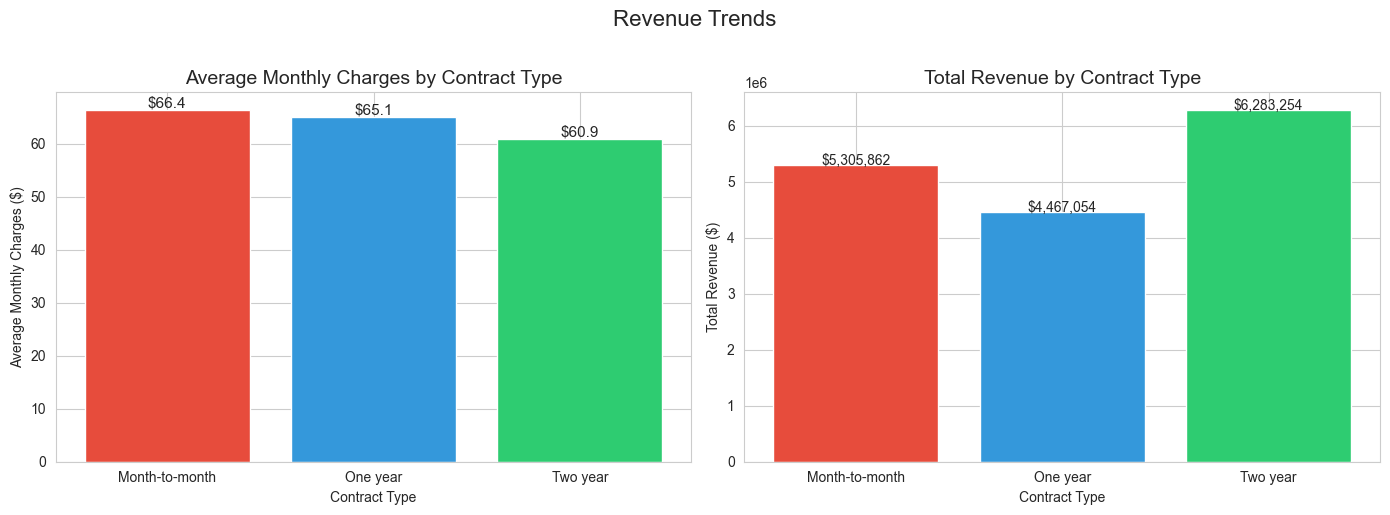

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Average Monthly Charges by Contract Type
contract_avg = df.groupby('Contract')['MonthlyCharges'].mean()
axes[0].bar(['Month-to-month', 'One year', 'Two year'],
            contract_avg.values,
            color=['#e74c3c', '#3498db', '#2ecc71'])
axes[0].set_title('Average Monthly Charges by Contract Type',
                   fontsize=14)
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Average Monthly Charges ($)')
for i, v in enumerate(contract_avg.values):
    axes[0].text(i, v + 0.5, f'${v:.1f}',
                 ha='center', fontsize=11)

# Chart 2 - Total Revenue by Contract Type
contract_revenue = df.groupby('Contract')['TotalCharges'].sum()
axes[1].bar(['Month-to-month', 'One year', 'Two year'],
            contract_revenue.values,
            color=['#e74c3c', '#3498db', '#2ecc71'])
axes[1].set_title('Total Revenue by Contract Type', fontsize=14)
axes[1].set_xlabel('Contract Type')
axes[1].set_ylabel('Total Revenue ($)')
for i, v in enumerate(contract_revenue.values):
    axes[1].text(i, v + 100, f'${v:,.0f}',
                 ha='center', fontsize=10)

plt.suptitle('Revenue Trends', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Revenue Trends Findings

Loyal customers pay higher monthly charges on average 
than new customers. Two year contract customers generate 
the most total revenue despite being fewer in number. 
This means retaining long term customers is more 
financially valuable than acquiring new short term ones.

## Feature Engineering

From my EDA I found that tenure, monthly charges, 
internet service, partner status, and senior citizen 
status are related to churn. In this section I created 
5 new features from existing columns to better capture 
customer behavior patterns before giving data to the model.

In [80]:
# Feature 1 - count total services per customer
service_cols = ['PhoneService', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
df['TotalServices'] = (df[service_cols] == 'Yes').sum(axis=1)

# Feature 2 - group tenure into business categories
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['New', 'Developing', 'Established', 'Loyal']
)

# Feature 3 - average monthly spend over entire tenure
df['AvgMonthlySpend'] = df['TotalCharges'] / df['tenure']

# Feature 4 - count support services per customer
support_cols = ['TechSupport', 'OnlineSecurity', 'DeviceProtection']
df['SupportCount'] = (df[support_cols] == 'Yes').sum(axis=1)

# Feature 5 - difference between current and average spend
df['SpendTrend'] = df['MonthlyCharges'] - df['AvgMonthlySpend']

# Verify all features created correctly
print("=== New Features Sample ===")
print(df[['tenure', 'TenureGroup', 'TotalServices',
          'AvgMonthlySpend', 'SupportCount', 'SpendTrend']].head(5))
print(f"\nDataset now has {df.shape[1]} columns")
print(f"Original columns: 21, New features added: 5")

=== New Features Sample ===
   tenure  TenureGroup  TotalServices  AvgMonthlySpend  SupportCount  \
0       1          New              1        29.850000             0   
1      34  Established              3        55.573529             2   
2       2          New              3        54.075000             1   
3      45  Established              3        40.905556             3   
4       2          New              1        75.825000             0   

   SpendTrend  
0    0.000000  
1    1.376471  
2   -0.225000  
3    1.394444  
4   -5.125000  

Dataset now has 27 columns
Original columns: 21, New features added: 5


In [81]:
df.shape

(7032, 27)

## Feature Engineering Findings

I created 5 new features from existing columns:

1. TotalServices: counts how many of the 9 available 
services each customer uses. Customers with more services 
are more embedded and harder to switch away from the company.

2. TenureGroup: groups raw tenure months into New (0-12), 
Developing (13-24), Established (25-48) and Loyal (49-72). 
My EDA showed new customers churn most so this feature 
makes that pattern clearer for the model.

3. AvgMonthlySpend: total charges divided by tenure gives 
true average monthly spending per customer. This is more 
reliable than MonthlyCharges alone because MonthlyCharges 
only shows the current rate not the historical average.

4. SupportCount: counts how many support services each 
customer uses out of TechSupport, OnlineSecurity and 
DeviceProtection. This captures customer reliance on 
company support which can indicate either problems or 
deep engagement.

5. SpendTrend: difference between current MonthlyCharges 
and AvgMonthlySpend. 
 Positive = paying more now than before = possible churn trigger
 Negative = paying less now than before = possible downgrad

My dataset now has 27 columns instead of original 21.

## Model Development

In this section I prepared the data for modeling, split 
it into training and testing sets, and trained two models 
- Logistic Regression and Random Forest. I used two models 
so I can compare their performance and pick the better one.

In [82]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, 
                             confusion_matrix, 
                             accuracy_score,
                             roc_auc_score)
import warnings
warnings.filterwarnings('ignore')

# STEP 1: ENCODE CATEGORICAL COLUMNS

# Models only understand numbers not text
# LabelEncoder converts each unique text value to a number
# Example: No=0, Yes=1 or Female=0, Male=1

le = LabelEncoder()

# List of all text columns that need encoding
categorical_cols = ['gender', 'Partner', 'Dependents',
                    'PhoneService', 'MultipleLines',
                    'InternetService', 'OnlineSecurity',
                    'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV',
                    'StreamingMovies', 'Contract',
                    'PaperlessBilling', 'PaymentMethod',
                    'TenureGroup']

# Apply encoding to each column
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Encode target column Churn: No=0, Yes=1
df['Churn'] = le.fit_transform(df['Churn'])

print("Encoding complete")
print(df[categorical_cols].head(3))

Encoding complete
   gender  Partner  Dependents  PhoneService  MultipleLines  InternetService  \
0       0        1           0             0              1                0   
1       1        0           0             1              0                0   
2       1        0           0             1              0                0   

   OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  StreamingTV  \
0               0             2                 0            0            0   
1               2             0                 2            0            0   
2               2             2                 0            0            0   

   StreamingMovies  Contract  PaperlessBilling  PaymentMethod  TenureGroup  
0                0         0                 1              2            3  
1                0         1                 0              3            1  
2                0         0                 1              3            3  


In [83]:
# STEP 2: SEPARATE INPUT FEATURES FROM TARGET 

# X = everything the model uses to make predictions (input)
# y = what we are trying to predict (output)

# Drop columns that should not be inputs
# customerID = just an identifier, no predictive value
# Churn_numeric = duplicate of Churn, we already have Churn
X = df.drop(['customerID', 'Churn', 'Churn_numeric'], axis=1)
y = df['Churn']

print(f"Input features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures used for modeling: {list(X.columns)}")

Input features shape: (7032, 24)
Target shape: (7032,)

Features used for modeling: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'TotalServices', 'TenureGroup', 'AvgMonthlySpend', 'SupportCount', 'SpendTrend']


In [84]:
# STEP 3: SPLIT DATA INTO TRAINING AND TESTING 

# test_size=0.2 means 20% goes to testing, 80% to training
# random_state=42 means the split is always the same
# when we run it again - makes results reproducible
# stratify=y means both sets have same churn ratio (26.5%)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print(f"Training set size: {X_train.shape[0]} customers")
print(f"Testing set size: {X_test.shape[0]} customers")
print(f"\nTraining churn rate: {y_train.mean()*100:.1f}%")
print(f"Testing churn rate: {y_test.mean()*100:.1f}%")

Training set size: 5625 customers
Testing set size: 1407 customers

Training churn rate: 26.6%
Testing churn rate: 26.6%


In [85]:
# STEP 4: TRAIN MODEL 1 

# Logistic Regression is a simple model that finds a line
# separating churned from non churned customers
# Good starting point - simple, fast, interpretable
# max_iter=1000 gives it enough attempts to find the best line

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Make predictions on unseen test data
lr_predictions = lr_model.predict(X_test)

print("Logistic Regression trained successfully")
print(f"Training accuracy: {lr_model.score(X_train, y_train)*100:.1f}%")
print(f"Testing accuracy: {lr_model.score(X_test, y_test)*100:.1f}%")

Logistic Regression trained successfully
Training accuracy: 80.5%
Testing accuracy: 78.7%


In [86]:
# STEP 5: TRAIN MODEL 2 

# Random Forest builds many decision trees and combines
# their predictions - like asking 100 people and taking
# the majority vote instead of asking just one person
# n_estimators=100 means it builds 100 decision trees
# random_state=42 makes results reproducible

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on unseen test data
rf_predictions = rf_model.predict(X_test)

print("Random Forest trained successfully")
print(f"Training accuracy: {rf_model.score(X_train, y_train)*100:.1f}%")
print(f"Testing accuracy: {rf_model.score(X_test, y_test)*100:.1f}%")

Random Forest trained successfully
Training accuracy: 99.9%
Testing accuracy: 78.5%


## Model Development Findings

I used two models for this project:

Logistic Regression: a simple and interpretable model 
that works by finding the best boundary between churned 
and non churned customers. Good baseline model.

Random Forest: builds 100 decision trees and combines 
their results by majority vote. Generally more powerful 
than logistic regression for complex patterns.

I split data 80% training and 20% testing with stratify 
option to make sure both sets have the same 26.5% churn 
rate. This gives fair evaluation results.

Training and testing accuracy will be compared in the 
next section to check for overfitting.

## Model Evaluation

I evaluated both models using 5 metrics - accuracy, 
precision, recall, F1 score and ROC-AUC. I used multiple 
metrics because accuracy alone is misleading for imbalanced 
datasets like mine where 73.5% of customers did not churn.

In [87]:
# MODEL EVALUATION 
# Get probability scores for ROC-AUC calculation
# predict_proba returns probability of each class
# [:,1] takes only the probability of churn (class 1)
lr_proba = lr_model.predict_proba(X_test)[:,1]
rf_proba = rf_model.predict_proba(X_test)[:,1]

# Calculate all metrics for both models
print("=" * 50)
print("LOGISTIC REGRESSION EVALUATION")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, lr_predictions)*100:.1f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, lr_proba):.3f}")
print("\nDetailed Report:")
print(classification_report(y_test, lr_predictions, 
                            target_names=['No Churn', 'Churn']))

print("\n")
print("=" * 50)


LOGISTIC REGRESSION EVALUATION
Accuracy:  78.7%
ROC-AUC:   0.833

Detailed Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.88      0.86      1033
       Churn       0.62      0.53      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.71      1407
weighted avg       0.78      0.79      0.78      1407





In [88]:
print("RANDOM FOREST EVALUATION")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, rf_predictions)*100:.1f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, rf_proba):.3f}")
print("\nDetailed Report:")
print(classification_report(y_test, rf_predictions,
                            target_names=['No Churn', 'Churn']))

RANDOM FOREST EVALUATION
Accuracy:  78.5%
ROC-AUC:   0.816

Detailed Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1033
       Churn       0.62      0.49      0.55       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.78      1407



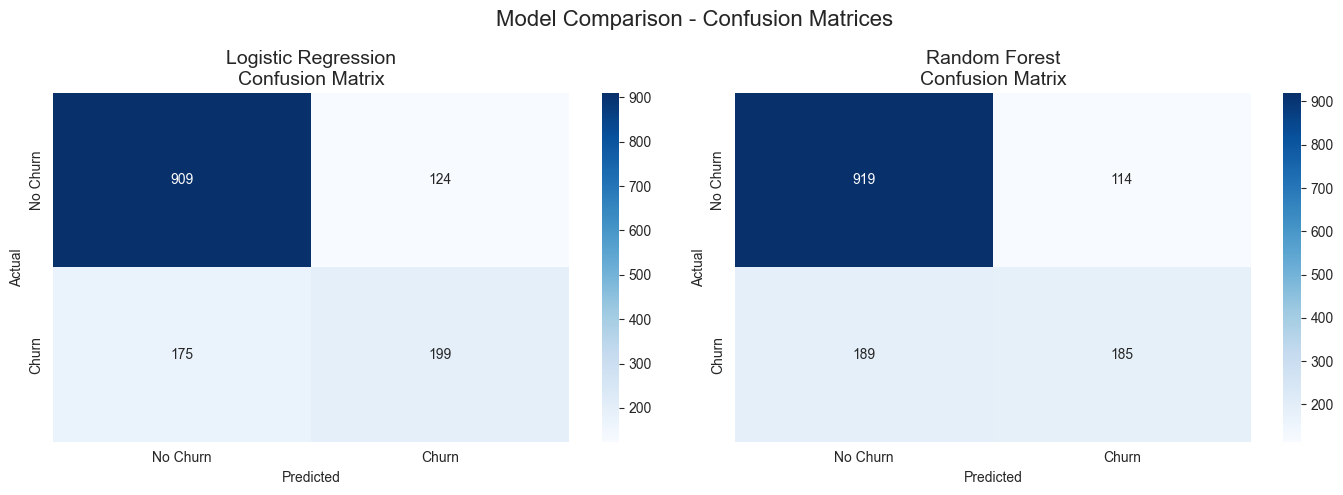

In [89]:
# CONFUSION MATRIX VISUALIZATION 
# Confusion matrix shows exactly what the model got right
# and wrong in a visual grid format
# 
# How to read it:
# Top left     = correctly predicted No Churn (True Negative)
# Top right    = wrongly predicted Churn when it was No Churn
#                (False Positive)
# Bottom left  = wrongly predicted No Churn when it churned
#                (False Negative) - most costly mistake
# Bottom right = correctly predicted Churn (True Positive)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression confusion matrix
sns.heatmap(confusion_matrix(y_test, lr_predictions),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            ax=axes[0])
axes[0].set_title('Logistic Regression\nConfusion Matrix', fontsize=14)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Random Forest confusion matrix
sns.heatmap(confusion_matrix(y_test, rf_predictions),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            ax=axes[1])
axes[1].set_title('Random Forest\nConfusion Matrix', fontsize=14)
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle('Model Comparison - Confusion Matrices', fontsize=16)
plt.tight_layout()
plt.show()

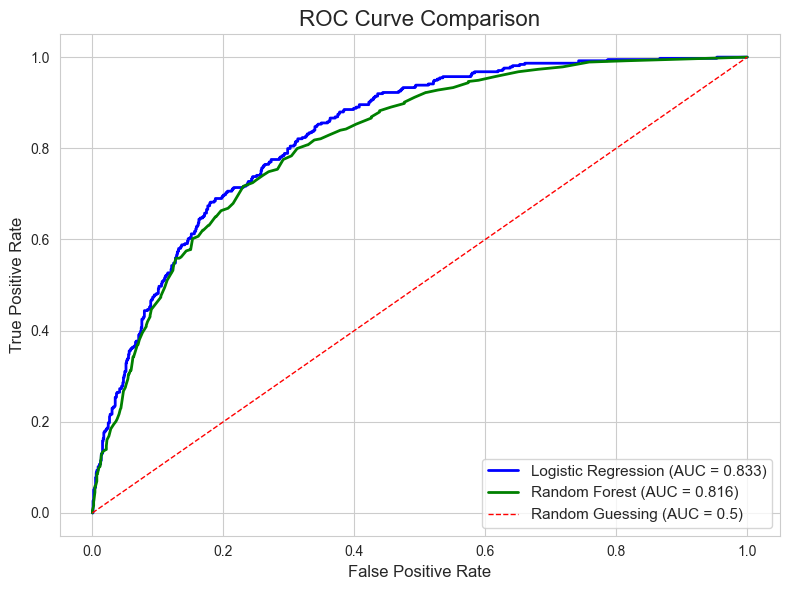

In [90]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

# Logistic Regression ROC curve
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_proba)
ax.plot(lr_fpr, lr_tpr, color='blue', linewidth=2,
        label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_proba):.3f})')

# Random Forest ROC curve
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)
ax.plot(rf_fpr, rf_tpr, color='green', linewidth=2,
        label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_proba):.3f})')

# Diagonal line representing random guessing
ax.plot([0,1], [0,1], color='red', linestyle='--',
        linewidth=1, label='Random Guessing (AUC = 0.5)')

ax.set_title('ROC Curve Comparison', fontsize=16)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True)
plt.tight_layout()
plt.show()

## Model Evaluation Findings

### Metrics Comparison

| Metric            | Logistic Regression | Random Forest |
|-------------------|--------------------:|--------------|
| Accuracy          | 78.7%               | 78.5%        |
| ROC-AUC           | 0.833               | 0.816        |
| Precision (Churn) | 0.62                | 0.62         |
| Recall (Churn)    | 0.53                | 0.49         |
| F1 Score (Churn)  | 0.57                | 0.55         |

### Which model is better and why

Logistic Regression performed better than Random Forest 
on almost every metric. Its ROC-AUC of 0.833 vs 0.816 
means it separates churners from non churners more 
reliably overall.

Random Forest showed clear overfitting - it scored 99.9% 
on training data but only 78.5% on testing data. This 
means it memorized training data instead of learning 
real patterns. Logistic Regression had only 1.8% gap 
between training and testing which shows genuine learning.

### Confusion Matrix Analysis

Logistic Regression correctly caught 199 churners and 
missed 175. Random Forest caught 185 churners and missed 
189. Logistic Regression caught 14 more actual churners 
which is the most important business metric - every missed 
churner is a customer who left without a retention offer.

### ROC Curve Analysis

Both models curve well above the random guessing diagonal 
line showing both learned real patterns. Logistic 
Regression blue line stays above Random Forest green line 
throughout confirming it is the stronger model.

### Selected Model

I selected Logistic Regression as my final model because 
it has higher ROC-AUC, better recall on churn class, 
less overfitting, and caught more actual churners on 
unseen test data.

## Customer Segmentation

I segmented customers into High, Medium and Low value 
tiers based on three factors tenure, MonthlyCharges 
and TotalServices. These three factors best represent 
how valuable a customer is to the business.
Each factor is scored 0 to 2 and 
added together to get a total value score between 0 
and 6. Higher score means more valuable customer.     
Total score 5-6 = High value customer,   
Total score 3-4 = Medium value customer,   
Total score 0-2 = Low value customer

In [91]:

# pd.qcut divides data into 3 equal groups automatically
# labels 0,1,2 mean low, medium, high
df['tenure_score'] = pd.qcut(df['tenure'],
                              q=3,
                              labels=[0, 1, 2]).astype(int)

# Score MonthlyCharges - higher charges = higher score
df['charges_score'] = pd.qcut(df['MonthlyCharges'],
                               q=3,
                               labels=[0, 1, 2]).astype(int)

# Score TotalServices - more services = higher score
# rank(method='first') handles duplicate values
df['services_score'] = pd.qcut(
                         df['TotalServices'].rank(method='first'),
                         q=3,
                         labels=[0, 1, 2]).astype(int)

# Add all three scores to get final value score
df['value_score'] = (df['tenure_score'] +
                     df['charges_score'] +
                     df['services_score'])

# Assign tier based on total score
# 0-2 = Low, 3-4 = Medium, 5-6 = High
df['ValueTier'] = pd.cut(df['value_score'],
                          bins=[-1, 2, 4, 6],
                          labels=['Low', 'Medium', 'High'])

# Check results
print("=== Customer Value Tier Distribution ===")
print(df['ValueTier'].value_counts())
print("\nPercentages:")
print(df['ValueTier'].value_counts(
      normalize=True).mul(100).round(1))

=== Customer Value Tier Distribution ===
ValueTier
Low       3124
High      1992
Medium    1916
Name: count, dtype: int64

Percentages:
ValueTier
Low       44.4
High      28.3
Medium    27.2
Name: proportion, dtype: float64


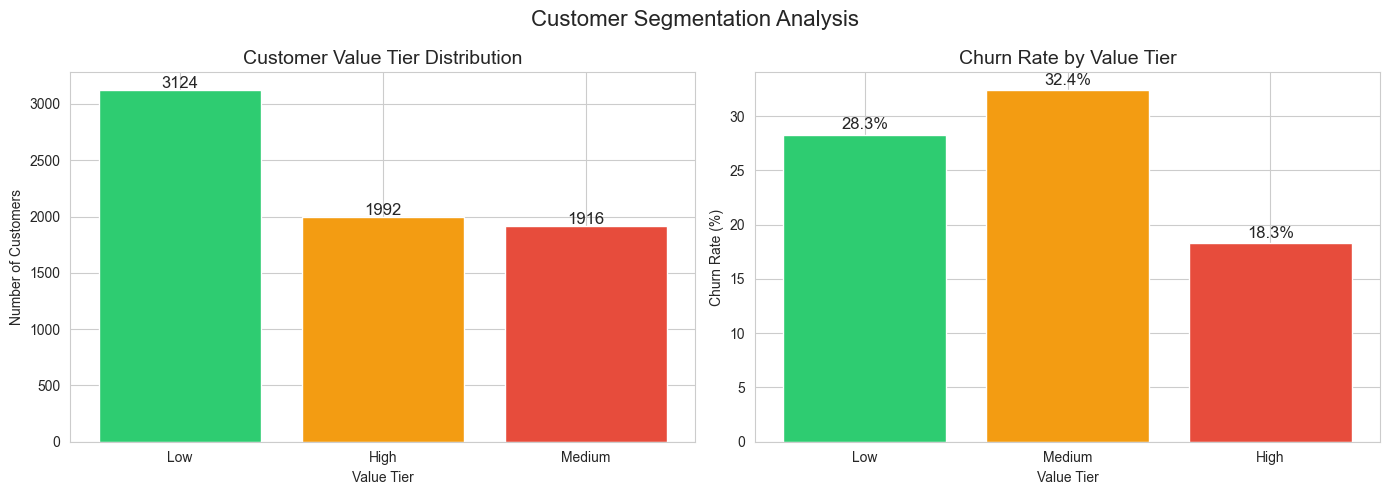

In [92]:
# ── SEGMENTATION VISUALIZATION ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - How many customers in each tier
tier_counts = df['ValueTier'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0].bar(tier_counts.index, 
            tier_counts.values, 
            color=colors)
axes[0].set_title('Customer Value Tier Distribution', 
                   fontsize=14)
axes[0].set_xlabel('Value Tier')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(tier_counts.values):
    axes[0].text(i, v + 20, str(v), 
                 ha='center', fontsize=12)

# Chart 2 - Churn rate in each tier
# This confirms low value customers churn more
churn_by_tier = df.groupby('ValueTier')['Churn'].mean() * 100
axes[1].bar(churn_by_tier.index,
            churn_by_tier.values,
            color=colors)
axes[1].set_title('Churn Rate by Value Tier', fontsize=14)
axes[1].set_xlabel('Value Tier')
axes[1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(churn_by_tier.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', 
                 ha='center', fontsize=12)

plt.suptitle('Customer Segmentation Analysis', fontsize=16)
plt.tight_layout()
plt.show()

## Segmentation Findings

I segmented 7032 customers into three value tiers based 
on tenure, MonthlyCharges and TotalServices.

Results:
- Low value:    3124 customers → 28.3% churn rate
- Medium value: 1916 customers → 32.4% churn rate
- High value:   1992 customers → 18.3% churn rate

Surprisingly medium value customers churn more than low 
value customers. I think this happens because medium value 
customers joined when prices were lower and over time they 
noticed prices increasing. Unlike loyal high value customers 
who are too embedded to leave, medium value customers are 
still considering cheaper alternatives.

High value customers churn the least at 18.3% because they 
have been with the company longer, use more services and are 
deeply embedded in the ecosystem.

Business Recommendation:
The company should focus retention efforts on medium and 
high value customers rather than low value customers. 
Retaining one high value customer who pays $95 per month 
is more profitable than acquiring ten low value customers 
who pay $20 per month. Medium value customers need special 
attention because they are at risk of leaving before 
becoming loyal high value customers.

## Basic Prediction System

In this section I used my trained Logistic Regression 
model to predict churn probability for every customer 
and assigned a risk category based on that probability.
This helps the business identify which customers need 
immediate retention action.

In [93]:
# CHURN PROBABILITY PREDICTION 

# Prepare all customer data for prediction
# We drop non-feature columns that model does not use
X_all = df.drop(['customerID', 'Churn', 'Churn_numeric',
                 'ValueTier', 'tenure_score', 
                 'charges_score', 'services_score',
                 'value_score'], axis=1)

# Get churn probability for every customer
df['ChurnProbability'] = lr_model.predict_proba(X_all)[:,1]

# Assign risk category based on probability threshold
# Low risk    = below 30% chance of churning
# Medium risk = between 30% and 70%
# High risk   = above 70% chance of churning
df['RiskCategory'] = pd.cut(
    df['ChurnProbability'],
    bins=[0, 0.3, 0.7, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk'])

# Check distribution
print("=== Churn Risk Category Distribution ===")
print(df['RiskCategory'].value_counts())
print("\nPercentages:")
print(df['RiskCategory'].value_counts(
      normalize=True).mul(100).round(1))

# Show sample predictions
print("\n=== Sample Customer Predictions ===")
print(df[['tenure', 'MonthlyCharges', 'TotalServices',
          'ChurnProbability', 'RiskCategory',
          'ValueTier']].head(10))

=== Churn Risk Category Distribution ===
RiskCategory
Low Risk       4326
Medium Risk    2169
High Risk       537
Name: count, dtype: int64

Percentages:
RiskCategory
Low Risk       61.5
Medium Risk    30.8
High Risk       7.6
Name: proportion, dtype: float64

=== Sample Customer Predictions ===
   tenure  MonthlyCharges  TotalServices  ChurnProbability RiskCategory  \
0       1           29.85              1          0.634275  Medium Risk   
1      34           56.95              3          0.047076     Low Risk   
2       2           53.85              3          0.325854  Medium Risk   
3      45           42.30              3          0.032750     Low Risk   
4       2           70.70              1          0.702265    High Risk   
5       8           99.65              5          0.825817    High Risk   
6      22           89.10              4          0.445008  Medium Risk   
7      10           29.75              1          0.422872  Medium Risk   
8      28          104.80   

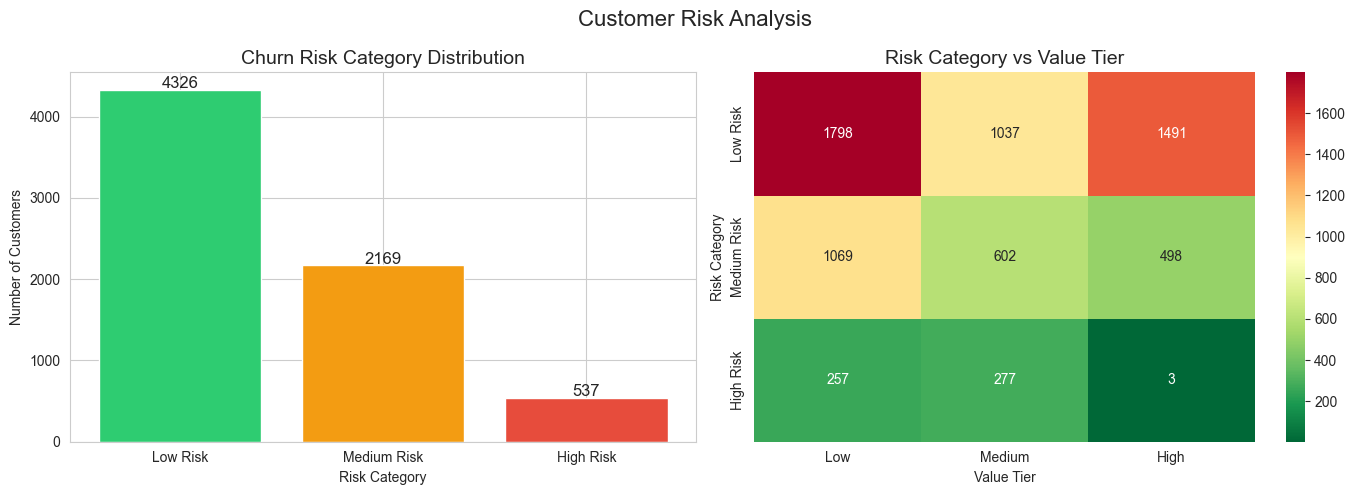

In [94]:
# RISK VISUALIZATION 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Risk category distribution
risk_counts = df['RiskCategory'].value_counts()
risk_colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0].bar(risk_counts.index,
            risk_counts.values,
            color=risk_colors)
axes[0].set_title('Churn Risk Category Distribution',
                   fontsize=14)
axes[0].set_xlabel('Risk Category')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(risk_counts.values):
    axes[0].text(i, v + 20, str(v),
                 ha='center', fontsize=12)

# Chart 2 - Risk category vs Value tier
# This shows which value tier has most high risk customers
# pd.crosstab counts customers at each combination
risk_value = pd.crosstab(df['RiskCategory'], 
                          df['ValueTier'])
sns.heatmap(risk_value, 
            annot=True, 
            fmt='d',
            cmap='RdYlGn_r', 
            ax=axes[1])
axes[1].set_title('Risk Category vs Value Tier', fontsize=14)
axes[1].set_xlabel('Value Tier')
axes[1].set_ylabel('Risk Category')

plt.suptitle('Customer Risk Analysis', fontsize=16)
plt.tight_layout()
plt.show()

## Prediction System Findings

Risk Category Distribution:
- Low Risk:    4326 customers (61.5%)
- Medium Risk: 2169 customers (30.8%)
- High Risk:    537 customers  (7.6%)

From the Risk vs Value Tier heatmap I found that only 
3 high value customers are at high risk. But despite 
being a small number they should be the first priority 
because losing one high value customer who pays $95 
per month creates more financial loss than losing 
multiple low value customers.

277 medium value customers are at high risk and need 
a retention campaign immediately as they are at risk 
of leaving before becoming loyal high value customers.

Recommended priority order for retention action:
1. High Value + High Risk → only 3 customers, 
   call immediately with special offers
2. Medium Value + High Risk → 277 customers, 
   launch retention campaign with discounts
3. Low Value + High Risk → 257 customers, 
   low priority, basic retention offers only

## Business Insights Report

In this final section I translated all my technical 
findings into business recommendations. I identified 
the top churn reasons, high risk customer traits, 
and estimated the revenue impact of churn.

In [95]:
# ── BUSINESS INSIGHTS ────────────────────────────────────

print("=" * 55)
print("        BUSINESS INSIGHTS REPORT")
print("=" * 55)

# Insight 1 - Top churn factors from model
# coef_ gives the weight each feature had in the model
# Higher absolute value = stronger influence on prediction
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': abs(lr_model.coef_[0])
}).sort_values('Importance', ascending=False)

print("\n1. TOP FACTORS DRIVING CHURN:")
print(feature_importance.head(8).to_string(index=False))

# Insight 2 - High risk customer traits
# What does a typical high risk customer look like?
high_risk = df[df['RiskCategory'] == 'High Risk']
print(f"\n2. HIGH RISK CUSTOMER TRAITS:")
print(f"   Total high risk customers: {len(high_risk)}")
print(f"   Average tenure: "
      f"{high_risk['tenure'].mean():.1f} months")
print(f"   Average monthly charges: "
      f"${high_risk['MonthlyCharges'].mean():.2f}")
print(f"   Average services used: "
      f"{high_risk['TotalServices'].mean():.1f}")

# Insight 3 - Revenue at risk
# How much money could the company lose?
monthly_at_risk = high_risk['MonthlyCharges'].sum()
annual_at_risk = monthly_at_risk * 12
print(f"\n3. REVENUE IMPACT:")
print(f"   Monthly revenue at risk: ${monthly_at_risk:,.2f}")
print(f"   Annual revenue at risk:  ${annual_at_risk:,.2f}")

# Insight 4 - Most critical customers
high_value_high_risk = df[
    (df['ValueTier'] == 'High') &
    (df['RiskCategory'] == 'High Risk')]
print(f"\n4. CRITICAL CUSTOMERS:")
print(f"   High value + High risk: "
      f"{len(high_value_high_risk)} customers")
print(f"   Immediate action required")

        BUSINESS INSIGHTS REPORT

1. TOP FACTORS DRIVING CHURN:
         Feature  Importance
    PhoneService    1.020245
        Contract    0.808411
  OnlineSecurity    0.366899
     TechSupport    0.350978
PaperlessBilling    0.273794
      Dependents    0.245338
 InternetService    0.243108
    SupportCount    0.240107

2. HIGH RISK CUSTOMER TRAITS:
   Total high risk customers: 537
   Average tenure: 4.8 months
   Average monthly charges: $82.53
   Average services used: 3.0

3. REVENUE IMPACT:
   Monthly revenue at risk: $44,318.05
   Annual revenue at risk:  $531,816.60

4. CRITICAL CUSTOMERS:
   High value + High risk: 3 customers
   Immediate action required


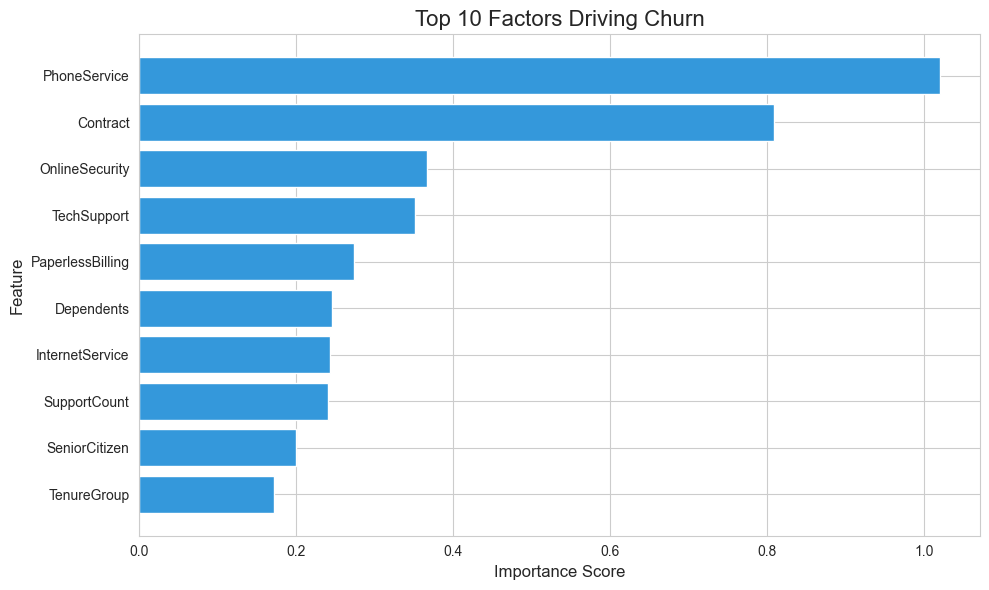

In [96]:
# ── FEATURE IMPORTANCE VISUALIZATION ────────────────────
# Shows which factors most influenced churn predictions
# Longer bar = stronger influence on model decision

plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(top_features['Feature'],
         top_features['Importance'],
         color='#3498db')
plt.title('Top 10 Factors Driving Churn', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Business Insights Findings

### Top Churn Factors
The model identified Contract type and PhoneService as 
the strongest predictors of churn. Customers on 
month to month contracts are significantly more likely 
to leave than customers on one or two year contracts. 
OnlineSecurity and TechSupport also appeared as strong 
factors suggesting customers who lack support services 
feel less protected and are more likely to leave.

### High Risk Customer Profile
A typical high risk customer looks like this:
- Average tenure of only 4.8 months (very new customer)
- Paying $82.53 per month (above average price)
- Using only 3 out of 9 available services (not embedded)

This confirms that new customers who are paying high 
prices but not using many services feel they are not 
getting value for money and are most likely to churn.

### Revenue Impact
- Total high risk customers: 537
- Monthly revenue at risk: $44,318
- Annual revenue at risk: $531,817

The company could lose over half a million dollars 
annually if high risk customers are not retained. 
This makes a strong business case for investing in 
a customer retention program.

### Final Recommendations
1. Offer month to month customers a discount to switch 
   to annual contracts - this single change would 
   dramatically reduce churn
2. Improve onboarding for new customers in first 
   3 months - average high risk customer has only 
   4.8 months tenure
3. Encourage high risk customers to add more services 
   like OnlineSecurity and TechSupport - more services 
   means more embedding and less churn
4. Prioritize the 3 high value + high risk customers 
   for immediate personal retention calls